<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [5]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2025-11-06 13:30:14--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  57.8MB/s    in 3.5s    

2025-11-06 13:30:19 (57.8 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [1]:
#!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 163.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 150.6 MB/s eta 0:00:00


In [2]:
#!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 140.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 142.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 154.4 MB/s eta 0:00:00


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import textwrap

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [2]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [3]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [4]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


In [5]:
#let's get a specific data set with no missing values for this analysis
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
df_ct = pd.read_sql_query(QUERY, conn)
df_ct.head()

,CompTotal
0,2040000.0
1,28000.0
2,85000.0
3,50000.0
4,110000.0


In [6]:
#let's see the description of CompTotal
df_ct.describe()

,CompTotal
count,3.374000e+04
mean,2.963841e+145
std,5.444117e+147
min,0.000000e+00
25%,6.000000e+04
50%,1.100000e+05
75%,2.500000e+05
max,1.000000e+150


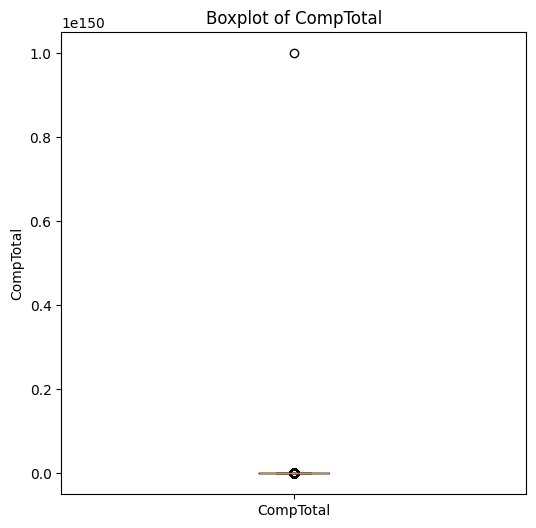

In [7]:
#plotting the box plot
plt.figure(figsize=(6, 6))
plt.boxplot(df_ct['CompTotal'], tick_labels=['CompTotal'])
plt.title('Boxplot of CompTotal')
plt.ylabel('CompTotal')
plt.show()

In [8]:
#we can do a better analysis by excluding outliers of CompTotal
#let's calculate the interquartile range for df_ct['CompTotal'] using the values produced by describe() (Q3  and Q1)
q3 = 2.500000e+05
q1 = 6.000000e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)

IQR =  190000.0
Upper bound for outliers =  535000.0
Lower bound for outliers =  -225000.0


+++As the minimum value is zero, we do not have to worry about the lower bound

In [9]:
df_ct_no_out = df_ct[df_ct['CompTotal'] <= 535000.0]
print(df_ct_no_out.describe())
df_ct_no_out.head()

           CompTotal
count   27864.000000
mean   117182.605369
std     99970.300622
min         0.000000
25%     50000.000000
50%     88000.000000
75%    150000.000000
max    535000.000000


,CompTotal
1,28000.0
2,85000.0
3,50000.0
4,110000.0
5,126420.0


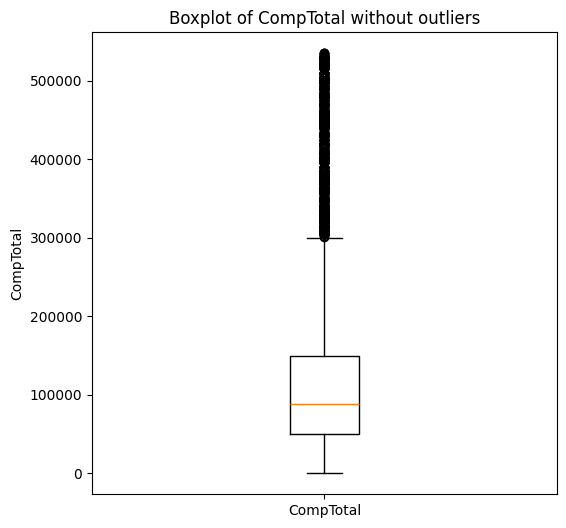

In [10]:
#let's now plot the boxplot without outliers
plt.figure(figsize=(6, 6))
plt.boxplot(df_ct_no_out['CompTotal'], tick_labels=['CompTotal'])
plt.title('Boxplot of CompTotal without outliers')
plt.ylabel('CompTotal')
plt.show()

+++Even excluding the outliers form the original daset, we still have a quite skewed distribution. The 'no outliers' dataset still has outliers if we consider its description. As I have already pointed out in previous labs, this variable has significative outliers that make the analysis difficult; moreover, the currency used for CompTotal is not homogeneous... It would be better to use ConvertedCompYearly, which is CompTotal converted to US Dollars.

**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [11]:
#Age is a categorical variable whose values are actually  age ranges (see item Demo 3). In order to plot a box plot, we first have to convert these categorical 
#values to numbers. Let's discard the rows with 'Prefer not to say' and convert the values in the other rows to the age range mean value.
#let's get from the database only rows where Age was informed
df_age = pd.read_sql_query('SELECT Age FROM main WHERE Age != "Prefer not to say" ', conn)
df_age.head()

,Age
0,Under 18 years old
1,35-44 years old
2,45-54 years old
3,18-24 years old
4,18-24 years old


In [12]:
df_age[['Age']].isna().mean()

Age    0.0
dtype: float64

+++no missing values in this column

In [13]:
#let's replace age ranges by range mean values
#let's assume 13.5 years for the 'Under 18 years old' range and 72.5 years for the '65 years or older' range
#For the other ranges let's take the the average of the two range limits
#we have, so:
numerical_ages = {'Under 18 years old': 13.5, '35-44 years old': 39.5, '45-54 years old': 49.5, '18-24 years old': 21.0, '25-34 years old':29.5, '55-64 years old': 59.5, '65 years or older': 72.5}
#let's replace the categorical values by the numerical values
df_age['Age'] = df_age['Age'].map(numerical_ages)
df_age.head()

,Age
0,13.5
1,39.5
2,49.5
3,21.0
4,21.0


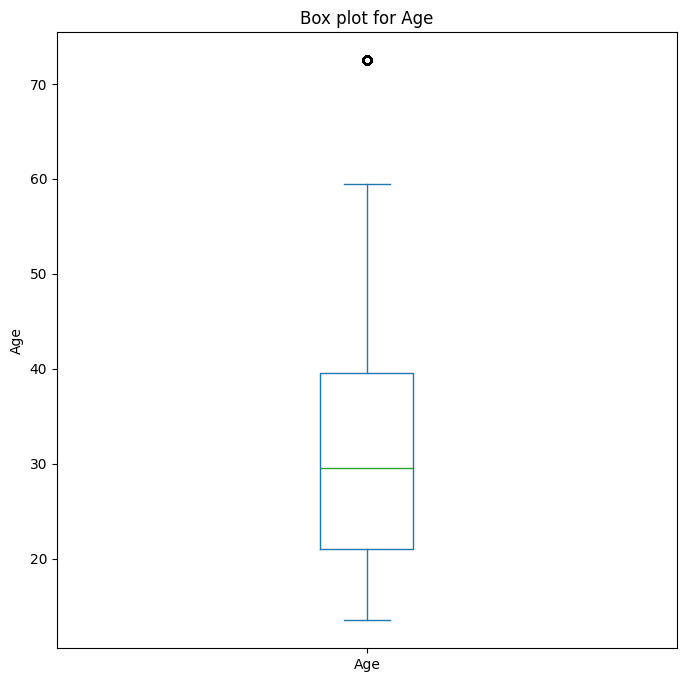

In [14]:
#let's plot the box plot for Age
df_age.plot(kind='box', figsize=(8, 8))

plt.title('Box plot for Age')
plt.ylabel('Age')
plt.ticklabel_format(style='plain', axis='y')
plt.show()

### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [15]:
#let's get a specific data set with no missing values for this analysis
QUERY = 'SELECT Age, CompTotal FROM main WHERE CompTotal IS NOT NULL AND Age != "Prefer not to say"'
df_ct_age = pd.read_sql_query(QUERY, conn)
df_ct_age.head(5)

,Age,CompTotal
0,18-24 years old,2040000.0
1,25-34 years old,28000.0
2,35-44 years old,85000.0
3,35-44 years old,50000.0
4,25-34 years old,110000.0


In [16]:
#let's exclude CompTotal outliers, as we have done before
df_ct_no_out_age = df_ct_age[df_ct_age['CompTotal'] <= 535000.0]
df_ct_no_out_age.head()

,Age,CompTotal
1,25-34 years old,28000.0
2,35-44 years old,85000.0
3,35-44 years old,50000.0
4,25-34 years old,110000.0
5,35-44 years old,126420.0


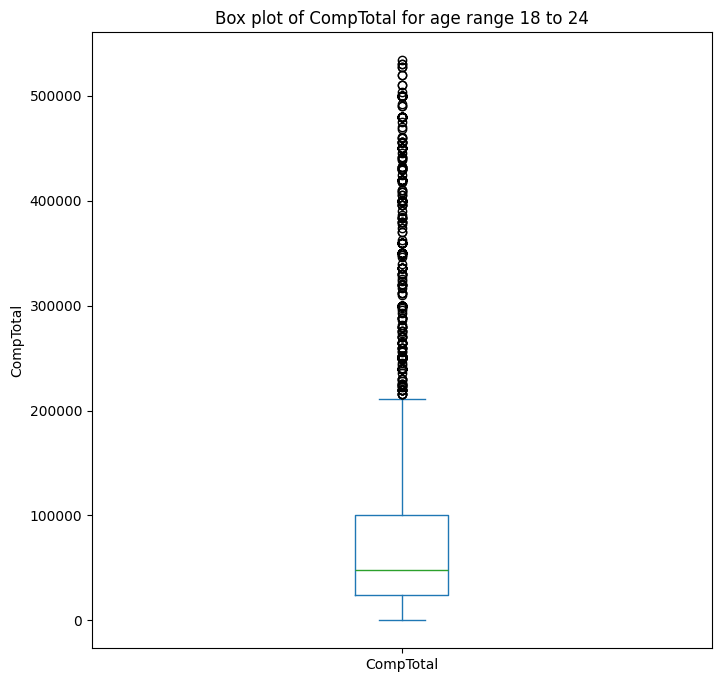

In [17]:
#let's plot for one age group
df_ct_no_out_age[df_ct_no_out_age['Age']=='18-24 years old'].plot(kind='box', figsize=(8, 8))
plt.title('Box plot of CompTotal for age range 18 to 24')
plt.ylabel('CompTotal')
plt.ticklabel_format(style='plain', axis='y')
plt.show()



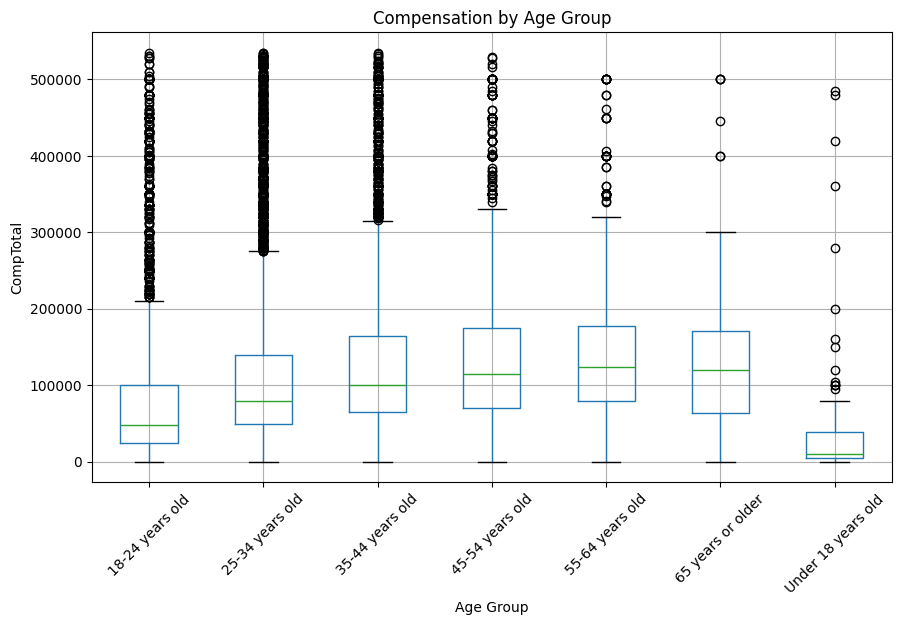

In [18]:
#let's plot for all Age groups
df_ct_no_out_age.boxplot(column='CompTotal', by='Age', figsize=(10,6), rot=45)
plt.title("Compensation by Age Group")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("Age Group")
plt.ylabel("CompTotal")
plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


In [19]:
#let's get a specific data set with no missing values for this analysis, and exclude outliers for CompTotal
QUERY = 'SELECT JobSatPoints_6, CompTotal FROM main WHERE CompTotal IS NOT NULL AND JobSatPoints_6 IS NOT NULL'
df_ct_js6 = pd.read_sql_query(QUERY, conn) 
df_ct_js6 = df_ct_js6[df_ct_js6['CompTotal'] <= 535000.0]
df_ct_js6.head(5)


,JobSatPoints_6,CompTotal
1,0.0,85000.0
2,20.0,110000.0
3,30.0,126420.0
4,30.0,195000.0
5,25.0,74000.0


In [20]:
df_ct_js6.describe()

,JobSatPoints_6,CompTotal
count,18425.000000,18425.000000
mean,24.148906,118862.956798
std,25.254131,99844.694568
min,0.000000,0.000000
25%,5.000000,52000.000000
50%,20.000000,90000.000000
75%,30.000000,150000.000000
max,100.000000,535000.000000


In [21]:
df_ct_js6['JobSatPoints_6'].nunique()

86

+++We have 86 different values, let's use point ranges intead of points (10 ranges)

In [22]:
bins = list(range(0, 101, 10))

labels = [
    '0 ≤ x ≤ 10',
    '10 < x ≤ 20',
    '20 < x ≤ 30',
    '30 < x ≤ 40',
    '40 < x ≤ 50',
    '50 < x ≤ 60',
    '60 < x ≤ 70',
    '70 < x ≤ 80',
    '80 < x ≤ 90',
    '90 < x ≤ 100'
]

df_ct_js6['JobSat6Cat'] = pd.cut(
    df_ct_js6['JobSatPoints_6'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)
df_ct_js6.head()

,JobSatPoints_6,CompTotal,JobSat6Cat
1,0.0,85000.0,0 ≤ x ≤ 10
2,20.0,110000.0,10 < x ≤ 20
3,30.0,126420.0,20 < x ≤ 30
4,30.0,195000.0,20 < x ≤ 30
5,25.0,74000.0,20 < x ≤ 30


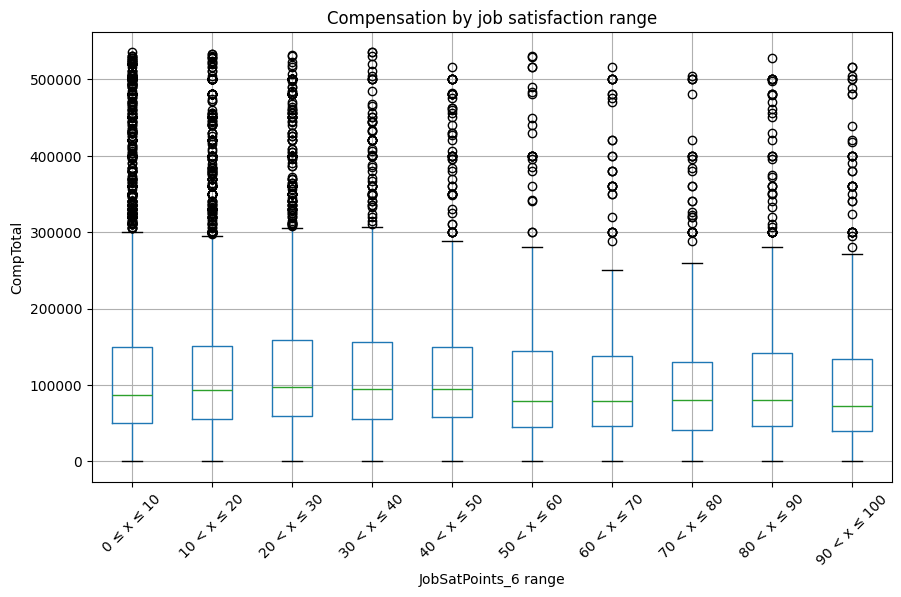

In [23]:
#let's plot for all Job Satisfaction ranges
df_ct_js6.boxplot(column='CompTotal', by='JobSat6Cat', figsize=(10,6), rot=45)
plt.title("Compensation by job satisfaction range")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("JobSatPoints_6 range")
plt.ylabel("CompTotal")
plt.show()

### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


In [24]:
#let's determine the top 5 developer types
QUERY = 'SELECT DevType FROM main WHERE DevType IS NOT NULL'
df_dt = pd.read_sql_query(QUERY, conn) 
df_dt=df_dt.groupby('DevType')[['DevType']].count()
df_dt.rename(columns={'DevType': 'DevType_count'}, inplace=True)
dev_top5 = df_dt.sort_values(by='DevType_count', ascending=False).head().reset_index()['DevType'].tolist()
dev_top5

['Developer, full-stack',
 'Developer, back-end',
 'Student',
 'Developer, front-end',
 'Developer, desktop or enterprise applications']

In [25]:
#now let's get a specific data set with no missing values for this analysis
QUERY = """SELECT DevType,ConvertedCompYearly FROM main WHERE ConvertedCompYearly IS NOT NULL AND DevType IN ('Developer, full-stack', 'Developer, back-end','Student',
           'Developer, front-end', 'Developer, desktop or enterprise applications') """
df_dt_ccy = pd.read_sql_query(QUERY, conn) 
df_dt_ccy.head(5)

,DevType,ConvertedCompYearly
0,"Developer, back-end",53703.0
1,Student,110000.0
2,"Developer, full-stack",195000.0
3,"Developer, full-stack",44586.0
4,"Developer, back-end",184712.0


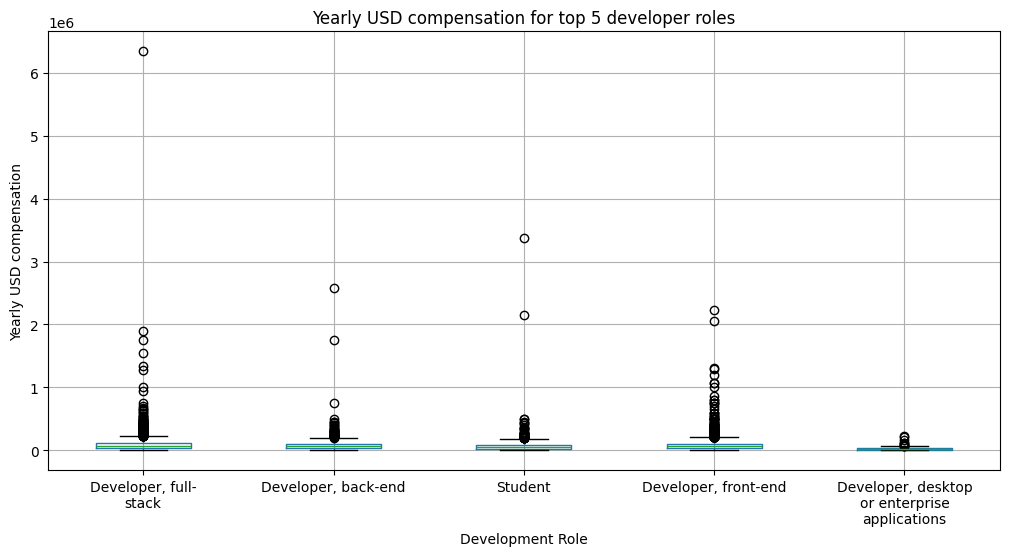

In [26]:
#let's plot the boxes for the top 5 DevTypes using wrapped labels on x-axis
wrapped_roles = [
    "\n".join(textwrap.wrap(label, width=20))
    for label in dev_top5]
ax = df_dt_ccy.boxplot(column='ConvertedCompYearly', by='DevType', figsize=(10,6))
ax.set_xticklabels(wrapped_roles, ha='center')
plt.tight_layout()
plt.title("Yearly USD compensation for top 5 developer roles")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("Development Role")
plt.ylabel("Yearly USD compensation")
plt.show()

+++There are ouliers which does not permit a better analysis, let's remove them

In [27]:
df_dt_ccy.describe()

,ConvertedCompYearly
count,1.564200e+04
mean,7.849832e+04
std,1.026437e+05
min,1.000000e+00
25%,3.007400e+04
50%,6.273450e+04
75%,1.020360e+05
max,6.340564e+06


In [28]:
#let's calculate the inter-quartile range for df_ct_ccy['ConvertedCompYearly'] using the values produced by describe() (Q3  and Q1)
q3 = 1.020360e+05
q1 = 3.007400e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)

IQR =  71962.0
Upper bound for outliers =  209979.0
Lower bound for outliers =  -77869.0


+++As the lower bound is negative, we do not have to worry with it

In [29]:
df_dt_ccy_no_out = df_dt_ccy[df_dt_ccy['ConvertedCompYearly'] <= 209979.0]
print(df_dt_ccy_no_out.describe())
df_dt_ccy_no_out.head()

       ConvertedCompYearly
count         15014.000000
mean          67356.657653
std           48746.572601
min               1.000000
25%           28880.500000
50%           59872.000000
75%           96666.000000
max          209000.000000


,DevType,ConvertedCompYearly
0,"Developer, back-end",53703.0
1,Student,110000.0
2,"Developer, full-stack",195000.0
3,"Developer, full-stack",44586.0
4,"Developer, back-end",184712.0


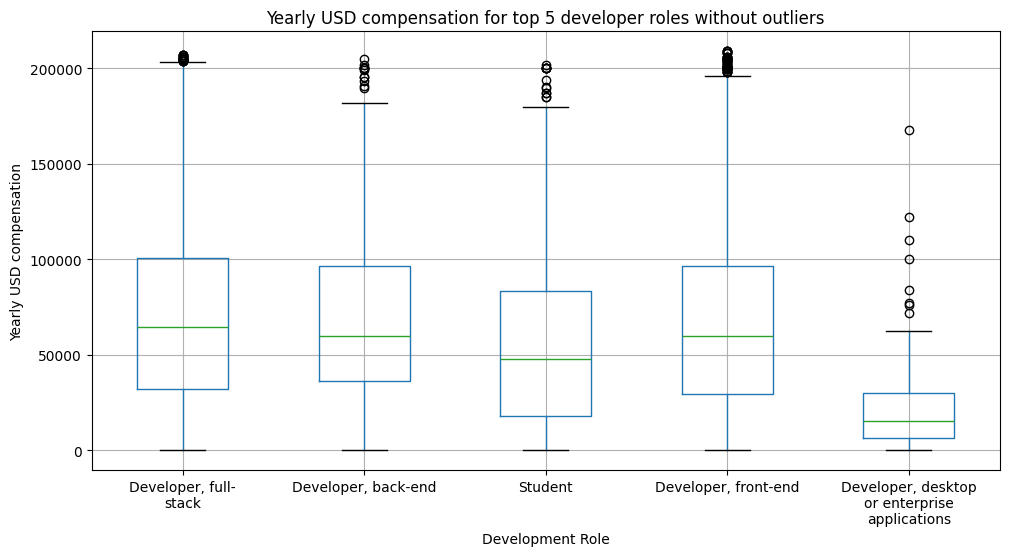

In [30]:
#let's plot the boxes for the top 5 DevTypes without outliers using wrapped labels on x-axis
wrapped_roles = [
    "\n".join(textwrap.wrap(label, width=20))
    for label in dev_top5]
ax = df_dt_ccy_no_out.boxplot(column='ConvertedCompYearly', by='DevType', figsize=(10,6))
ax.set_xticklabels(wrapped_roles, ha='center')
plt.tight_layout()
plt.title("Yearly USD compensation for top 5 developer roles without outliers")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("Development Role")
plt.ylabel("Yearly USD compensation")
plt.show()

Analyze compensation across respondents from the top 5 countries.


In [31]:
#let's determine the top 5 countries
QUERY = 'SELECT Country FROM main WHERE Country IS NOT NULL'
df_cy = pd.read_sql_query(QUERY, conn) 
df_cy=df_cy.groupby('Country')[['Country']].count()
df_cy.rename(columns={'Country': 'Country_count'}, inplace=True)
country_top5 = df_cy.sort_values(by='Country_count', ascending=False).head().reset_index()['Country'].tolist()
country_top5

['United States of America',
 'Germany',
 'India',
 'United Kingdom of Great Britain and Northern Ireland',
 'Ukraine']

In [32]:
#now let's get a specific data set with no missing values for this analysis
QUERY = """SELECT Country, ConvertedCompYearly FROM main WHERE ConvertedCompYearly IS NOT NULL AND Country IN ('United States of America', 'Germany', 'India',
           'United Kingdom of Great Britain and Northern Ireland', 'Ukraine') """
df_cy_ccy = pd.read_sql_query(QUERY, conn) 
df_cy_ccy.head(5)

,Country,ConvertedCompYearly
0,United States of America,110000.0
1,United Kingdom of Great Britain and Northern I...,161044.0
2,United Kingdom of Great Britain and Northern I...,121018.0
3,United States of America,195000.0
4,United Kingdom of Great Britain and Northern I...,184712.0


+++let's remove outliers for a better analysis

In [33]:
df_cy_ccy.describe()

,ConvertedCompYearly
count,1.062500e+04
mean,1.076245e+05
std,1.165419e+05
min,1.000000e+00
25%,4.833300e+04
50%,8.807300e+04
75%,1.449980e+05
max,4.936778e+06


In [34]:
#let's calculate the inter-quartile range for df_cy_ccy['ConvertedCompYearly'] using the values produced by describe() (Q3  and Q1)
q3 = 1.449980e+05
q1 = 4.833300e+04
iqr = q3 - q1
print('IQR = ', iqr)
#let's calculate the upper and lower bound for outliers
out_upper = q3 + 1.5 * iqr
print('Upper bound for outliers = ', out_upper)
out_lower = q1 - 1.5 * iqr
print('Lower bound for outliers = ', out_lower)

IQR =  96665.0
Upper bound for outliers =  289995.5
Lower bound for outliers =  -96664.5


In [35]:
df_cy_ccy_no_out = df_cy_ccy[df_cy_ccy['ConvertedCompYearly'] <= 289995.5]
print(df_cy_ccy_no_out.describe())
df_cy_ccy_no_out.head()

       ConvertedCompYearly
count         10250.000000
mean          94081.125854
std           64245.565471
min               1.000000
25%           46185.000000
50%           85000.000000
75%          135000.000000
max          286623.000000


,Country,ConvertedCompYearly
0,United States of America,110000.0
1,United Kingdom of Great Britain and Northern I...,161044.0
2,United Kingdom of Great Britain and Northern I...,121018.0
3,United States of America,195000.0
4,United Kingdom of Great Britain and Northern I...,184712.0


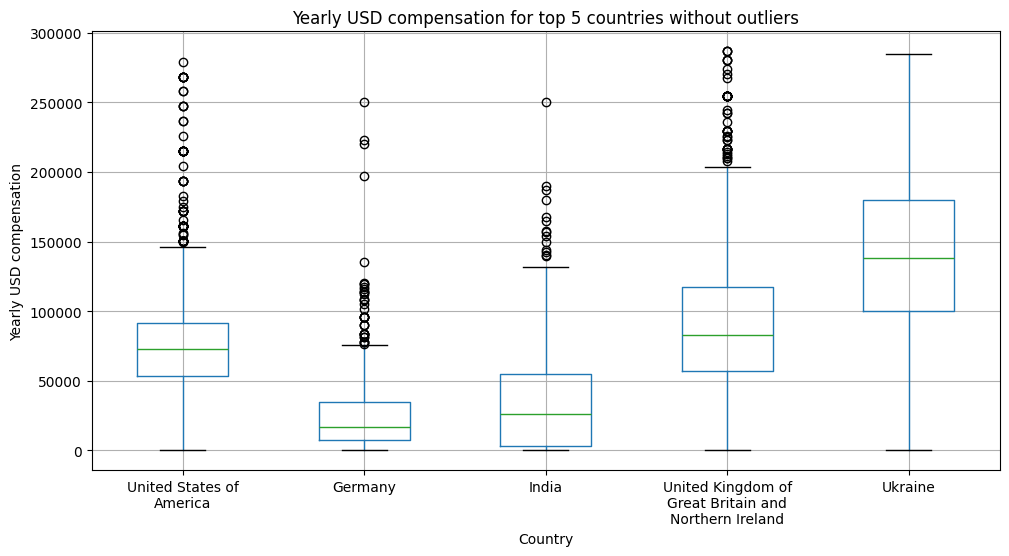

In [36]:
#let's plot the boxes for the top 5 countries without outliers using wrapped labels on x-axis
wrapped_roles = [
    "\n".join(textwrap.wrap(label, width=20))
    for label in country_top5]
ax = df_cy_ccy_no_out.boxplot(column='ConvertedCompYearly', by='Country', figsize=(10,6))
ax.set_xticklabels(wrapped_roles, ha='center')
plt.tight_layout()
plt.title("Yearly USD compensation for top 5 countries without outliers")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("Country")
plt.ylabel("Yearly USD compensation")
plt.show()

### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [37]:
#let's get a specific data set with no missing values for this analysis
QUERY = "SELECT Employment, CompTotal FROM main WHERE CompTotal IS NOT NULL AND Employment IS NOT NULL"
df_et_ct = pd.read_sql_query(QUERY, conn) 
df_et_ct.head()

,Employment,CompTotal
0,"Employed, full-time;Student, full-time;Indepen...",2040000.0
1,"Employed, full-time",28000.0
2,"Employed, full-time",85000.0
3,"Independent contractor, freelancer, or self-em...",50000.0
4,"Employed, full-time;Student, part-time",110000.0


In [38]:
#Employment is a column with multiple options, let's transform the dataframe creating a new column with a single option
df_et_ct = df_et_ct.assign(EmpType=df_et_ct['Employment'].str.split(';')).explode('EmpType')

In [39]:
df_et_ct.head()

,Employment,CompTotal,EmpType
0,"Employed, full-time;Student, full-time;Indepen...",2040000.0,"Employed, full-time"
0,"Employed, full-time;Student, full-time;Indepen...",2040000.0,"Student, full-time"
0,"Employed, full-time;Student, full-time;Indepen...",2040000.0,"Independent contractor, freelancer, or self-em..."
0,"Employed, full-time;Student, full-time;Indepen...",2040000.0,"Employed, part-time"
1,"Employed, full-time",28000.0,"Employed, full-time"


In [40]:
#for a better analysis, let's exclude CompTotal outliers
df_et_ct = df_et_ct[df_et_ct['CompTotal'] <= 535000.0]

In [17]:
df_et_ct.head()

,Employment,CompTotal,EmpType
1,"Employed, full-time",28000.0,"Employed, full-time"
2,"Employed, full-time",85000.0,"Employed, full-time"
3,"Independent contractor, freelancer, or self-em...",50000.0,"Independent contractor, freelancer, or self-em..."
4,"Employed, full-time;Student, part-time",110000.0,"Employed, full-time"
4,"Employed, full-time;Student, part-time",110000.0,"Student, part-time"


In [41]:
#let's get the unique values of employment type
emp_types = df_et_ct['EmpType'].unique().tolist()
emp_types

['Employed, full-time',
 'Independent contractor, freelancer, or self-employed',
 'Student, part-time',
 'Student, full-time',
 'Employed, part-time',
 'Retired',
 'Not employed, but looking for work',
 'Not employed, and not looking for work']

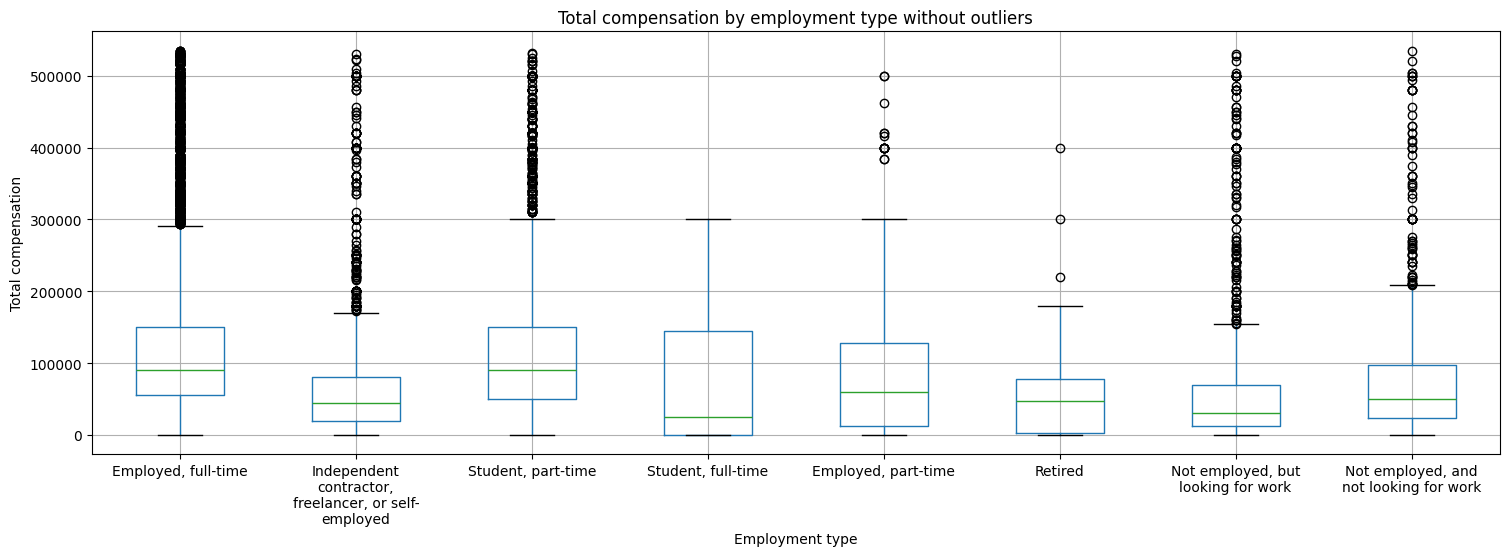

In [42]:
#let's plot the boxes of CompTotal for each employment type, without outliers and using wrapped labels on x-axis
wrapped_labels = [
    "\n".join(textwrap.wrap(label, width=20))
    for label in emp_types]
ax = df_et_ct.boxplot(column='CompTotal', by='EmpType', figsize=(15,6))
ax.set_xticklabels(wrapped_labels, ha='center')
plt.tight_layout()
plt.title("Total compensation by employment type without outliers")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("Employment type")
plt.ylabel("Total compensation")
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [43]:
#let's get a specific data set with no missing values for this analysis
QUERY = "SELECT YearsCodePro, JobSatPoints_6 FROM main WHERE YearsCodePro IS NOT NULL AND JobSatPoints_6 IS NOT NULL"
df_ycp_js6 = pd.read_sql_query(QUERY, conn) 
df_ycp_js6.head()

,YearsCodePro,JobSatPoints_6
0,17,0.0
1,12,30.0
2,27,0.0
3,10,60.0
4,Less than 1 year,100.0


In [44]:
df_ycp_js6.nunique()

YearsCodePro      52
JobSatPoints_6    93
dtype: int64

In [45]:
#We have 93 unique values for job satisfaction, let's use ranges instead of points
bins = list(range(0, 101, 10))

labels = [
    '0 ≤ x ≤ 10',
    '10 < x ≤ 20',
    '20 < x ≤ 30',
    '30 < x ≤ 40',
    '40 < x ≤ 50',
    '50 < x ≤ 60',
    '60 < x ≤ 70',
    '70 < x ≤ 80',
    '80 < x ≤ 90',
    '90 < x ≤ 100'
]

df_ycp_js6['JobSat6Cat'] = pd.cut(
    df_ycp_js6['JobSatPoints_6'],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)
df_ycp_js6.head()

,YearsCodePro,JobSatPoints_6,JobSat6Cat
0,17,0.0,0 ≤ x ≤ 10
1,12,30.0,20 < x ≤ 30
2,27,0.0,0 ≤ x ≤ 10
3,10,60.0,50 < x ≤ 60
4,Less than 1 year,100.0,90 < x ≤ 100


In [34]:
df_ycp_js6['YearsCodePro'].unique()

array(['17', '12', '27', '10', 'Less than 1 year', '18', '15', '6', '7',
       '16', '14', '4', '8', '2', '29', '5', '30', '1', '25', '24', '26',
       '9', '20', '37', '11', '3', '13', '19', '21', '23', '34', '28',
       '32', '22', '33', '40', '39', '31', '35', '41', '38',
       'More than 50 years', '36', '43', '42', '50', '45', '44', '46',
       '48', '47', '49'], dtype=object)

In [46]:
#let's convert YearsCodePro to numeric
mapping = {'Less than 1 year': 0.0, 'More than 50 years': 50.0}
df_ycp_js6['YearsCodePro'] = df_ycp_js6['YearsCodePro'].replace(mapping).astype(float)
print(df_ycp_js6['YearsCodePro'].unique())
df_ycp_js6.head()

[17. 12. 27. 10.  0. 18. 15.  6.  7. 16. 14.  4.  8.  2. 29.  5. 30.  1.
 25. 24. 26.  9. 20. 37. 11.  3. 13. 19. 21. 23. 34. 28. 32. 22. 33. 40.
 39. 31. 35. 41. 38. 50. 36. 43. 42. 45. 44. 46. 48. 47. 49.]


,YearsCodePro,JobSatPoints_6,JobSat6Cat
0,17.0,0.0,0 ≤ x ≤ 10
1,12.0,30.0,20 < x ≤ 30
2,27.0,0.0,0 ≤ x ≤ 10
3,10.0,60.0,50 < x ≤ 60
4,0.0,100.0,90 < x ≤ 100


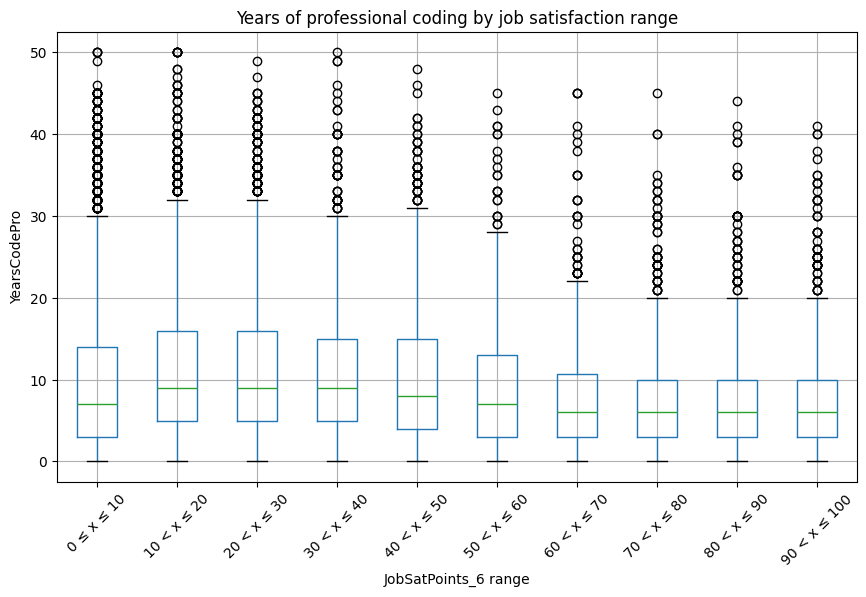

In [47]:
#let's plot the boxes for all Job Satisfaction ranges
df_ycp_js6.boxplot(column='YearsCodePro', by='JobSat6Cat', figsize=(10,6), rot=45)
plt.title("Years of professional coding by job satisfaction range")
plt.suptitle("")   # removes default Pandas title
plt.xlabel("JobSatPoints_6 range")
plt.ylabel("YearsCodePro")
plt.show()

### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [48]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
